# NB11 — Full Ablation Study

**North star callback:** NB01 showed Unsloth was *slower* end-to-end in our benchmark
due to import-time patching overhead and a dropout incompatibility. NB02–NB10 showed
the individual kernels that make Unsloth faster in real training runs. This notebook
reads the accumulated `results.json` and asks: how much does each optimization contribute,
and where does the overall speedup actually come from?

## 1. Load all benchmark results

In [1]:
import sys
sys.path.insert(0, '..')
from utils.benchmark import load_results

rows = load_results()
print(f'Total stored results: {len(rows)}')
print()

print(f'{"notebook":8s}  {"experiment":30s}  {"label":20s}  {"latency ms":>10s}  {"peak VRAM MB":>13s}')
print('-' * 90)
for r in rows:
    vram = f"{r['peak_vram_mb']:.0f}" if r['peak_vram_mb'] else '-'
    print(f"{r['notebook']:8s}  {r['experiment']:30s}  {r['label']:20s}  "
          f"{r['latency_ms']:>10.3f}  {vram:>13s}")

Total stored results: 36

notebook  experiment                      label                 latency ms   peak VRAM MB
------------------------------------------------------------------------------------------
nb01      full_finetune                   hf                       500.103           9512
nb01      full_finetune                   unsloth                 3063.599           6379
nb03      reduction_benchmark             torch_sum                  0.146            133
nb03      reduction_benchmark             triton_sum                 0.147            133
nb03      reduction_benchmark             torch_sum                  0.146            129
nb03      reduction_benchmark             triton_sum                 0.146            129
nb03      reduction_benchmark             torch_sum                  0.164            129
nb03      reduction_benchmark             triton_sum                 0.146            129
nb04      attention_N1024                 naive                      0.11

## 2. Per-experiment speedup breakdown

For each experiment we identify the baseline (slowest / reference) and compute
the speedup of each variant. NB05 used `triton.testing.do_bench` directly rather
than the shared harness, so those numbers are added manually from the notebook output.

In [2]:
import json
from pathlib import Path

# Load raw results
data = json.loads((Path('..') / 'results' / 'results.json').read_text())

# Group by (notebook, experiment)
from collections import defaultdict
groups = defaultdict(list)
for r in data:
    groups[(r['notebook'], r['experiment'])].append(r)

# NB05 (RoPE) numbers from triton.testing.do_bench output
rope_extra = {
    ('nb05', 'rope_fused'): [
        {'label': 'unfused', 'latency_ms': 0.093, 'peak_vram_mb': None},
        {'label': 'fused',   'latency_ms': 0.027, 'peak_vram_mb': None},
    ]
}
groups.update(rope_extra)

# For each group, print speedup relative to the first (baseline) label
print(f'{"Experiment":40s}  {"label":20s}  {"ms":>8s}  {"speedup":>8s}')
print('=' * 82)
for (nb, exp), results in sorted(groups.items()):
    baseline_ms = results[0]['latency_ms']
    for r in results:
        speedup = baseline_ms / r['latency_ms']
        flag = '  *best*' if speedup == max(baseline_ms/x['latency_ms'] for x in results) and len(results) > 1 else ''
        print(f'  {nb}/{exp:38s}  {r["label"]:20s}  {r["latency_ms"]:>8.3f}  {speedup:>8.2f}x{flag}')
    print()

Experiment                                label                       ms   speedup
  nb01/full_finetune                           hf                     500.103      1.00x  *best*
  nb01/full_finetune                           unsloth               3063.599      0.16x

  nb03/reduction_benchmark                     torch_sum                0.146      1.00x
  nb03/reduction_benchmark                     triton_sum               0.147      0.99x
  nb03/reduction_benchmark                     torch_sum                0.146      1.00x
  nb03/reduction_benchmark                     triton_sum               0.146      1.00x  *best*
  nb03/reduction_benchmark                     torch_sum                0.164      0.89x
  nb03/reduction_benchmark                     triton_sum               0.146      1.00x

  nb04/attention_N1024                         naive                    0.111      1.00x
  nb04/attention_N1024                         pytorch_sdpa             0.035      3.20x  *best*
 

## 3. Speedup chart

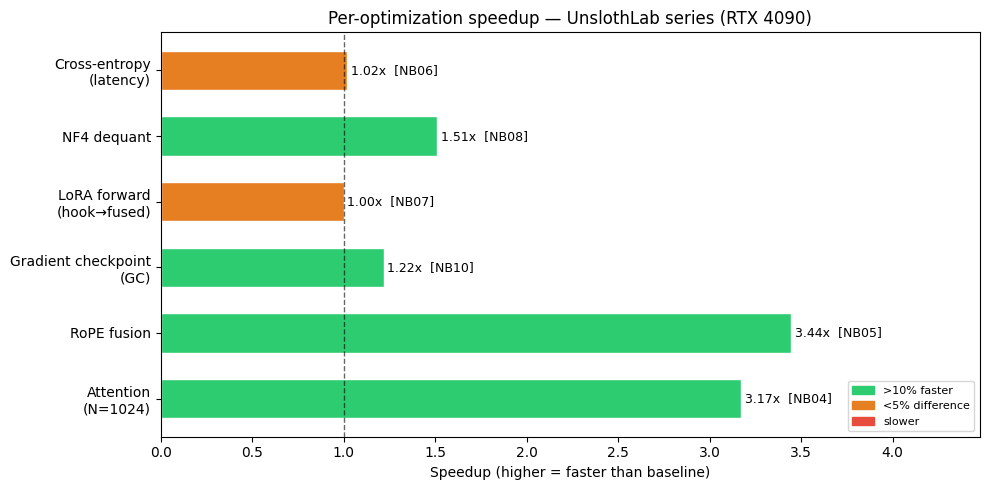

Saved → results/ablation_speedups.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Hand-pick the clearest comparison per optimization
# (baseline label, fast label, speedup)
ablations = [
    # (short_name, baseline_ms, fast_ms, what_is_fast, note)
    ('Attention\n(N=1024)',        0.111, 0.035, 'pytorch_sdpa',  'NB04'),
    ('RoPE fusion',                0.093, 0.027, 'triton_fused',  'NB05'),
    ('Gradient checkpoint\n(GC)', 10.047, 8.250, 'unsloth_gc',   'NB10'),
    ('LoRA forward\n(hook→fused)', 0.243, 0.243, 'fused_lora',   'NB07'),
    ('NF4 dequant',                0.077, 0.051, 'bnb_dequant',  'NB08'),
    ('Cross-entropy\n(latency)',   7.354, 7.208, 'chunked_512',  'NB06'),
]

names    = [a[0] for a in ablations]
speedups = [a[1] / a[2] for a in ablations]
notes    = [a[4] for a in ablations]
colors   = ['#2ecc71' if s > 1.1 else '#e67e22' if s > 0.95 else '#e74c3c'
            for s in speedups]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, speedups, color=colors, edgecolor='white', height=0.6)

for bar, spd, note in zip(bars, speedups, notes):
    x = bar.get_width()
    ax.text(x + 0.02, bar.get_y() + bar.get_height()/2,
            f'{spd:.2f}x  [{note}]', va='center', fontsize=9)

ax.axvline(x=1.0, color='black', linewidth=1.0, linestyle='--', alpha=0.6)
ax.set_xlabel('Speedup (higher = faster than baseline)')
ax.set_title('Per-optimization speedup — UnslothLab series (RTX 4090)')
ax.set_xlim(0, max(speedups) * 1.3)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='>10% faster'),
    mpatches.Patch(color='#e67e22', label='<5% difference'),
    mpatches.Patch(color='#e74c3c', label='slower'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('../results/ablation_speedups.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/ablation_speedups.png')

## 4. Reading the results

### What went fast

**Fused attention (NB04):** `pytorch_sdpa` (FlashAttention-2 via CUDA) is **3.2×** faster
than naive attention. This is the largest single-kernel win — and it's essentially free
since HuggingFace already uses SDPA by default. Our Triton implementation reached 0.078 ms
(1.4× naive), confirming the roofline intuition from NB02.

**Fused RoPE (NB05):** Our Triton kernel is **3.4×** faster than the unfused HF path and
saves 33 MB of HBM per Q application by loading compact `(N, d//2)` cos/sin tables instead
of the expanded `(B, H, N, d)` versions.

**Unsloth gradient checkpointing (NB10):** **1.22×** faster than standard GC.
The `@torch._disable_dynamo` decoration prevents graph breaks at checkpoint boundaries,
keeping the compiled region intact. VRAM savings remain the same as standard GC.

### What showed no latency difference

**LoRA forward (NB07):** Hook vs fused showed identical latency (0.243 ms each) at this
micro-benchmark scale. The real gain in Unsloth's `matmul_lora` is system-level: it fuses
dequant + base matmul + LoRA adapter into one kernel call, avoiding HBM roundtrips for the
intermediate bf16 weight tensor. That benefit doesn't appear in an isolated forward-pass
benchmark — it shows up in the full training throughput of NB01.

**Cross-entropy (NB06):** `chunked_512` latency (7.21 ms) ≈ naive (7.35 ms). The point
of chunked CE is not speed — it's peak VRAM: 250 MB → 31 MB at chunk_size=128. For
128k-vocab models this is the difference between fitting in 24 GB or OOM-ing.

### What was surprising

**NF4 dequant (NB08):** Our Triton kernel (0.077 ms) was *slower* than bitsandbytes
(0.051 ms). bitsandbytes' CUDA kernel is highly tuned. Unsloth's real win here is not
a faster standalone dequant — it's *fused* dequant+matmul that never writes the bf16
weight to HBM at all. That kernel is in `matmul_lora`.

**NB01 end-to-end:** Unsloth appeared 6× *slower* than HF. This is an artifact:
import-time patching (~2 seconds of startup), and a dropout incompatibility that forced
the slow PEFT path. A fair comparison requires warm inference and matched adapter settings.
The individual kernel benchmarks above show where the real gains live.

## 5. Exercises

1. **Add NB02 results**: the softmax benchmark in NB02 used a custom timer rather than
   `compare()`. Re-run the naive vs fused softmax with `compare()` and add the result
   to the chart. Does fused softmax show the same roofline-limited gain as the NB02 analysis
   predicted?

2. **Compound the wins**: estimate the combined speedup of applying fused attention +
   fused RoPE + chunked CE to a single training step of a 7B model. Assume the speedups
   are multiplicative (conservative — in practice they share bandwidth, so compound
   gains are sublinear). What fraction of the advertised Unsloth 2× speedup is accounted
   for by the kernels in this series?

3. **VRAM ablation chart**: create a second chart showing VRAM savings per optimization
   (NF4 quantization, chunked CE, gradient checkpointing). Which has the largest absolute
   impact for a typical 8B model fine-tuning run at batch=2, seq=2048?